In [1]:
import os, time, random, warnings
warnings.filterwarnings("ignore")
 
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms.functional import rotate as tvrotate
from torchvision import transforms

def set_seed(s: int = 42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
 
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")

device : cuda


In [2]:
DATA_DIR   = "/kaggle/input/datasets/vitthal2945/e2e-hidden-symmetries-dataset"
OUT_DIR    = "/kaggle/working/exp2_angle_conditioned_flow"
LATENT_DIM = 16   # must match Task-1 VAE
 
EPOCHS_ORACLE = 15
EPOCHS_F      = 60
BATCH_SIZE    = 256
LR_F          = 3e-4
 
# Training angles used for multi-angle supervision (a subset keeps cost manageable)
TRAIN_ANGLES_DEG = [30, 60, 90, 120, 150, 180]
 
# Loss weights
W_SUP    = 1.0   # multi-angle supervised
W_ADD    = 0.3   # angle additivity
W_DIV    = 0.05  # Jacobian divergence (volume preservation)
W_ORACLE = 0.1   # oracle class preservation
 
TASK1_CKPT = "/kaggle/input/models/vitthal2945/e2e-vaemodel/pytorch/default/1/best_model.pt"
 
os.makedirs(OUT_DIR, exist_ok=True)
print(f"output → {OUT_DIR}")

output → /kaggle/working/exp2_angle_conditioned_flow


In [3]:
def load_h5(path: str):
    print(f"  loading {os.path.basename(path)} ...", end=" ", flush=True)
    t0 = time.time()
    with h5py.File(path, "r") as f:
        imgs   = torch.from_numpy(f["images"][:].astype("float32")).unsqueeze(1)
        labels = torch.from_numpy(f["labels"][:].astype("int64"))
        angles = torch.from_numpy(f["angles"][:].astype("int64"))
    imgs = imgs.clamp(0., 1.)
    print(f"done  ({imgs.nbytes/1e6:.0f} MB, {time.time()-t0:.1f}s)")
    return imgs, labels, angles
 
train_imgs, train_lbls, train_angs = load_h5(os.path.join(DATA_DIR, "rotated_mnist_train.h5"))
test_imgs,  test_lbls,  test_angs  = load_h5(os.path.join(DATA_DIR, "rotated_mnist_test.h5"))
 
ANGLES  = sorted(train_angs.unique().tolist())
DIGITS  = sorted(train_lbls.unique().tolist())
DIG_MAP = {d: i for i, d in enumerate(DIGITS)}
TARGET  = [a for a in ANGLES if a != 0]
 
pin = device.type == "cuda"
train_loader = DataLoader(TensorDataset(train_imgs, train_lbls, train_angs),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=pin)
test_loader  = DataLoader(TensorDataset(test_imgs, test_lbls, test_angs),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=pin)
print(f"train: {len(train_imgs):,}   test: {len(test_imgs):,}")

  loading rotated_mnist_train.h5 ... done  (478 MB, 3.1s)
  loading rotated_mnist_test.h5 ... done  (82 MB, 0.4s)
train: 152,400   test: 26,004


In [4]:
class ResBlock(nn.Module):
    def __init__(self, ch, g=8):
        super().__init__()
        g = min(g, ch)
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch), nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch),
        )
        self.act = nn.SiLU()
    def forward(self, x): return self.act(x + self.net(x))
 
class T1Encoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.stem  = nn.Sequential(nn.Conv2d(1, 32, 4, 2, 1, bias=False), nn.GroupNorm(8, 32),  nn.SiLU())
        self.l1    = nn.Sequential(ResBlock(32),  nn.Conv2d(32,  64, 4, 2, 1, bias=False), nn.GroupNorm(8, 64),  nn.SiLU())
        self.l2    = nn.Sequential(ResBlock(64),  nn.Conv2d(64, 128, 3, 2, 1, bias=False), nn.GroupNorm(8, 128), nn.SiLU())
        self.l3    = ResBlock(128)
        self.fc    = nn.Sequential(nn.Flatten(), nn.Linear(128*4*4, 512), nn.SiLU())
        self.fc_mu = nn.Linear(512, ld)
        self.fc_lv = nn.Linear(512, ld)
    def forward(self, x):
        h = self.l3(self.l2(self.l1(self.stem(x))))
        h = self.fc(h)
        return self.fc_mu(h), self.fc_lv(h)
 
class T1Decoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(ld, 512), nn.SiLU(), nn.Linear(512, 128*4*4), nn.SiLU())
        self.u1 = nn.Sequential(ResBlock(128), nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1), nn.GroupNorm(8, 64),  nn.SiLU())
        self.u2 = nn.Sequential(ResBlock(64),  nn.ConvTranspose2d(64,  32, 4, 2, 1),                  nn.GroupNorm(8, 32),  nn.SiLU())
        self.u3 = nn.Sequential(ResBlock(32),  nn.ConvTranspose2d(32,   1, 4, 2, 3),                  nn.Sigmoid())
    def forward(self, z): return self.u3(self.u2(self.u1(self.fc(z).view(-1, 128, 4, 4))))
 
class Task1VAE(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.encoder = T1Encoder(ld)
        self.decoder = T1Decoder(ld)
    def reparameterise(self, mu, lv):
        return mu + torch.randn_like(mu) * (0.5 * lv).exp() if self.training else mu
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)
    def forward(self, x):
        mu, lv = self.encoder(x)
        return self.decoder(self.reparameterise(mu, lv)), mu, lv
 
vae = Task1VAE(LATENT_DIM).to(device)
if os.path.exists(TASK1_CKPT):
    ckpt = torch.load(TASK1_CKPT, map_location=device, weights_only=False)
    vae.load_state_dict(ckpt["model"])
    print(f"Task-1 VAE loaded (epoch {ckpt['epoch']})")
else:
    print("⚠ Task-1 checkpoint not found — VAE weights are random (replace TASK1_CKPT)")
 
vae.eval()
for p in vae.parameters():
    p.requires_grad = False

Task-1 VAE loaded (epoch 47)


In [5]:
class Oracle(nn.Module):
    def __init__(self, ld, nc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(ld, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 32),  nn.ReLU(),
            nn.Linear(32, nc),
        )
    def forward(self, z): return self.net(z)
 
psi = Oracle(LATENT_DIM, len(DIGITS)).to(device)
opt_psi = torch.optim.Adam(psi.parameters(), lr=1e-3)
print(f"\nTraining Oracle for {EPOCHS_ORACLE} epochs …")
 
for ep in range(1, EPOCHS_ORACLE + 1):
    psi.train(); correct = total = 0
    for imgs, lbls, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        cls  = torch.tensor([DIG_MAP[l.item()] for l in lbls], device=device)
        with torch.no_grad():
            mu, _ = vae.encode(imgs)
        opt_psi.zero_grad()
        logits = psi(mu)
        F.cross_entropy(logits, cls).backward()
        opt_psi.step()
        correct += (logits.detach().argmax(1) == cls).sum().item()
        total   += imgs.size(0)
    if ep % 5 == 0 or ep == 1:
        print(f"  Oracle ep {ep:2d}/{EPOCHS_ORACLE}  acc={correct/total:.4f}")
 
psi.eval()
for p in psi.parameters():
    p.requires_grad = False
print("Oracle frozen.")


Training Oracle for 15 epochs …
  Oracle ep  1/15  acc=0.9849
  Oracle ep  5/15  acc=0.9886
  Oracle ep 10/15  acc=0.9888
  Oracle ep 15/15  acc=0.9892
Oracle frozen.


In [6]:
class AngleConditionedFlow(nn.Module):
    """
    Maps (z, θ) → z_θ  where θ is given as Fourier features [sin θ, cos θ, sin 2θ, cos 2θ].
 
    Architecture: two-tower fusion
      - z tower: projects z to hidden dim
      - θ tower: projects angle features to hidden dim
      - fusion MLP: shared processing then output displacement δz
      - z_θ = z + δz(z, θ)   ← residual formulation keeps output near input
 
    The residual structure means that at θ≈0, δz≈0, which is correct.
    """
    ANGLE_FEATS = 4   # sin θ, cos θ, sin 2θ, cos 2θ
 
    def __init__(self, ld: int, hidden: int = 256):
        super().__init__()
        angle_in = self.ANGLE_FEATS
 
        self.z_proj   = nn.Sequential(nn.Linear(ld, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.ang_proj = nn.Sequential(nn.Linear(angle_in, hidden), nn.LayerNorm(hidden), nn.GELU())
 
        self.fusion = nn.Sequential(
            nn.Linear(hidden * 2, hidden * 2), nn.LayerNorm(hidden * 2), nn.GELU(),
            nn.Linear(hidden * 2, hidden),     nn.LayerNorm(hidden),     nn.GELU(),
            nn.Linear(hidden, hidden),         nn.GELU(),
            nn.Linear(hidden, ld),
        )
        # small init: start near identity (zero displacement)
        nn.init.uniform_(self.fusion[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.fusion[-1].bias)
 
    @staticmethod
    def angle_features(theta_deg: float, batch_size: int, dev) -> torch.Tensor:
        """Return [sin θ, cos θ, sin 2θ, cos 2θ] replicated to (B, 4)."""
        th = torch.tensor(theta_deg * np.pi / 180., dtype=torch.float32)
        feats = torch.stack([th.sin(), th.cos(), (2*th).sin(), (2*th).cos()])  # (4,)
        return feats.unsqueeze(0).expand(batch_size, -1).to(dev)
 
    def forward(self, z: torch.Tensor, theta_deg: float) -> torch.Tensor:
        ang = self.angle_features(theta_deg, z.size(0), z.device)
        hz  = self.z_proj(z)
        ha  = self.ang_proj(ang)
        dz  = self.fusion(torch.cat([hz, ha], dim=1))
        return z + dz   # residual: z_theta = z + delta(z, theta)
 
F_net = AngleConditionedFlow(LATENT_DIM).to(device)
print(f"\nAngle-Conditioned Flow params: {sum(p.numel() for p in F_net.parameters()):,}")


Angle-Conditioned Flow params: 472,080


In [7]:
def hutchinson_divergence(F_net: nn.Module, z: torch.Tensor, theta_deg: float) -> torch.Tensor:
    """Estimate tr(∂F/∂z) using one Rademacher sample.
    For a volume-preserving map this should be zero."""
    z = z.detach().requires_grad_(True)
    F_out = F_net(z, theta_deg)
    v = torch.randint_like(z, high=2).float() * 2 - 1   # ±1 Rademacher
    vjp, = torch.autograd.grad(F_out, z, grad_outputs=v, create_graph=True)
    div  = (vjp * v).sum(dim=1).mean()
    return div.abs()

In [8]:
print("\n── Phase 2: Angle-Conditioned Flow (multi-angle supervised) ──────")
 
opt_F   = torch.optim.AdamW(F_net.parameters(), lr=LR_F, weight_decay=1e-5)
sched_F = torch.optim.lr_scheduler.CosineAnnealingLR(opt_F, T_max=EPOCHS_F)
 
history = {k: [] for k in ["sup", "add", "div", "oracle", "total", "val_90"]}
best_val = float("inf")
 
# Pre-compute rotated images for training angles (cache on GPU is expensive;
# we rotate on-the-fly per batch which is faster on GPU)
print(f"  Training angles: {TRAIN_ANGLES_DEG}")
 
for ep in range(1, EPOCHS_F + 1):
    F_net.train()
    acc = {k: 0.0 for k in ["sup", "add", "div", "oracle"]}
    n_batches = 0
 
    for imgs, _, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
 
        with torch.no_grad():
            z0, _ = vae.encode(imgs)
            psi_z0 = psi(z0)
 
        opt_F.zero_grad(set_to_none=True)
 
        # ── L_sup: multi-angle supervised ──────────────────────────────────
        l_sup = torch.tensor(0., device=device)
        for theta in TRAIN_ANGLES_DEG:
            xr = tvrotate(imgs, float(theta),
                          interpolation=transforms.InterpolationMode.BILINEAR,
                          fill=[0.])
            with torch.no_grad():
                z_gt, _ = vae.encode(xr)
            z_pred   = F_net(z0, float(theta))
            l_sup    = l_sup + F.mse_loss(z_pred, z_gt)
        l_sup = l_sup / len(TRAIN_ANGLES_DEG)
 
        # ── L_add: angle additivity  F(F(z,α),β) ≈ F(z,α+β) ───────────────
        # sample two random additive angle pairs
        a1, a2 = 30, 60   # 30+60=90 is always a valid training target
        z_a1   = F_net(z0, float(a1))
        z_a1a2 = F_net(z_a1.detach(), float(a2))  # detach inner to avoid 2nd-order
        with torch.no_grad():
            z_sum = F_net(z0, float(a1 + a2))
        l_add  = F.mse_loss(z_a1a2, z_sum.detach())
 
        # ── L_div: Hutchinson volume-preservation penalty ───────────────────
        l_div = hutchinson_divergence(F_net, z0.detach(), 30.)
 
        # ── L_oracle: class preservation at 30° ────────────────────────────
        z_30  = F_net(z0, 30.)
        l_oracle = F.mse_loss(psi(z_30), psi_z0.detach())
 
        loss = W_SUP * l_sup + W_ADD * l_add + W_DIV * l_div + W_ORACLE * l_oracle
        loss.backward()
        nn.utils.clip_grad_norm_(F_net.parameters(), 1.0)
        opt_F.step()
 
        acc["sup"]    += l_sup.item()
        acc["add"]    += l_add.item()
        acc["div"]    += l_div.item()
        acc["oracle"] += l_oracle.item()
        n_batches += 1
 
    sched_F.step()
    for k in acc: acc[k] /= n_batches
    total = (W_SUP * acc["sup"] + W_ADD * acc["add"] +
             W_DIV * acc["div"] + W_ORACLE * acc["oracle"])
 
    # ── validation: direct 90° prediction (no composition needed) ──────────
    F_net.eval()
    with torch.no_grad():
        pool = (test_angs == 0).nonzero(as_tuple=True)[0][:300]
        x_val = test_imgs[pool].to(device)
        z_val, _ = vae.encode(x_val)
        x90_val  = tvrotate(x_val, 90., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        z_gt90, _ = vae.encode(x90_val)
        z_pred90 = F_net(z_val, 90.)
        val_90   = F.mse_loss(z_pred90, z_gt90).item()
    F_net.train()
 
    for k in acc: history[k].append(acc[k])
    history["total"].append(total)
    history["val_90"].append(val_90)
 
    if val_90 < best_val:
        best_val = val_90
        torch.save({"F": F_net.state_dict(), "psi": psi.state_dict(), "epoch": ep,
                    "val_90": best_val}, os.path.join(OUT_DIR, "best_model.pt"))
        tag = "  ★"
    else:
        tag = ""
 
    if ep % 5 == 0 or ep == 1 or tag:
        print(f"  ep {ep:3d}/{EPOCHS_F}  sup={acc['sup']:.5f}  add={acc['add']:.5f}  "
              f"div={acc['div']:.5f}  val_90={val_90:.5f}{tag}")
 
ck = torch.load(os.path.join(OUT_DIR, "best_model.pt"), weights_only=False)
F_net.load_state_dict(ck["F"]); psi.load_state_dict(ck["psi"])
F_net.eval()
print(f"Best model loaded (epoch {ck['epoch']}, val_90={ck['val_90']:.5f})")


── Phase 2: Angle-Conditioned Flow (multi-angle supervised) ──────
  Training angles: [30, 60, 90, 120, 150, 180]
  ep   1/60  sup=0.01524  add=0.00608  div=1.86547  val_90=0.00455  ★
  ep   2/60  sup=0.00566  add=0.00213  div=0.67301  val_90=0.00294  ★
  ep   3/60  sup=0.00478  add=0.00203  div=0.59770  val_90=0.00271  ★
  ep   5/60  sup=0.00375  add=0.00143  div=0.51981  val_90=0.00206  ★
  ep  10/60  sup=0.00305  add=0.00115  div=0.46077  val_90=0.00194  ★
  ep  14/60  sup=0.00277  add=0.00096  div=0.35453  val_90=0.00169  ★
  ep  15/60  sup=0.00279  add=0.00094  div=0.37762  val_90=0.00192
  ep  17/60  sup=0.00272  add=0.00087  div=0.37275  val_90=0.00166  ★
  ep  20/60  sup=0.00262  add=0.00082  div=0.33618  val_90=0.00184
  ep  21/60  sup=0.00256  add=0.00073  div=0.32977  val_90=0.00160  ★
  ep  24/60  sup=0.00244  add=0.00072  div=0.29206  val_90=0.00157  ★
  ep  25/60  sup=0.00240  add=0.00070  div=0.27523  val_90=0.00166
  ep  27/60  sup=0.00236  add=0.00065  div=0.29033  va

In [9]:
@torch.no_grad()
def evaluate():
    pool = (test_angs == 0).nonzero(as_tuple=True)[0][:500]
    x0   = test_imgs[pool].to(device)
    z0, _ = vae.encode(x0)
 
    # M1 — direct angle prediction (no rollout — F is angle-conditioned!)
    m1_per = {}
    for theta in TARGET:
        xr = tvrotate(x0, float(theta), interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        z_gt, _ = vae.encode(xr)
        z_pred  = F_net(z0, float(theta))
        m1_per[theta] = F.mse_loss(z_pred, z_gt).item()
    m1_mean = float(np.mean(list(m1_per.values())))
 
    # M2 — oracle drift via F(z, 360°)
    z360  = F_net(z0, 360.)
    p0    = torch.softmax(psi(z0), dim=1)
    m2    = F.mse_loss(torch.softmax(psi(z360), dim=1), p0).item()
 
    # M3 — step norm at 30°
    dz30 = F_net(z0, 30.) - z0
    m3m  = dz30.norm(dim=1).mean().item()
    m3s  = dz30.norm(dim=1).std().item()
 
    # M4 — angle additivity error (30+60=90)
    z30  = F_net(z0, 30.)
    z_comp = F_net(z30, 60.)
    z_dir  = F_net(z0,  90.)
    m4     = F.mse_loss(z_comp, z_dir).item()
 
    # M5 — pixel-space MSE at 90° (decode predicted latent vs actual rotated image)
    x90     = tvrotate(x0, 90., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
    z90_pred = F_net(z0, 90.)
    m5      = F.mse_loss(vae.decode(z90_pred).clamp(0.,1.), x90).item()
 
    return m1_per, m1_mean, m2, m3m, m3s, m4, m5
 
m1_per, m1_mean, m2, m3m, m3s, m4, m5 = evaluate()
print("\n══════════════ FINAL METRICS ══════════════")
print(f"M1 Latent MSE (mean, direct)   : {m1_mean:.5f}")
for theta, v in m1_per.items():
    print(f"     θ={theta:4d}°  →  {v:.5f}")
print(f"M2 Oracle drift (360° direct)  : {m2:.5f}")
print(f"M3 Step norm 30°  mean ± std   : {m3m:.4f} ± {m3s:.4f}")
print(f"M4 Angle additivity (30+60=90) : {m4:.5f}")
print(f"M5 Pixel MSE at 90°            : {m5:.5f}")
print("═══════════════════════════════════════════")
 
np.save(os.path.join(OUT_DIR, "metrics.npy"), {
    "exp": "EXP2_ANGLE_CONDITIONED_FLOW",
    "m1_per_angle": m1_per, "m1_mean": m1_mean,
    "m2_oracle_drift": m2,
    "m3_norm_mean": m3m, "m3_norm_std": m3s,
    "m4_additivity": m4,
    "m5_pixel_mse_90": m5,
    "history": history,
}, allow_pickle=True)


══════════════ FINAL METRICS ══════════════
M1 Latent MSE (mean, direct)   : 0.01928
     θ=  30°  →  0.01027
     θ=  60°  →  0.00121
     θ=  90°  →  0.00140
     θ= 120°  →  0.00133
     θ= 150°  →  0.00096
     θ= 180°  →  0.00113
     θ= 210°  →  0.01977
     θ= 240°  →  0.01516
     θ= 270°  →  0.02889
     θ= 300°  →  0.06821
     θ= 330°  →  0.06376
M2 Oracle drift (360° direct)  : 0.00011
M3 Step norm 30°  mean ± std   : 0.6191 ± 0.2384
M4 Angle additivity (30+60=90) : 0.00036
M5 Pixel MSE at 90°            : 0.03946
═══════════════════════════════════════════


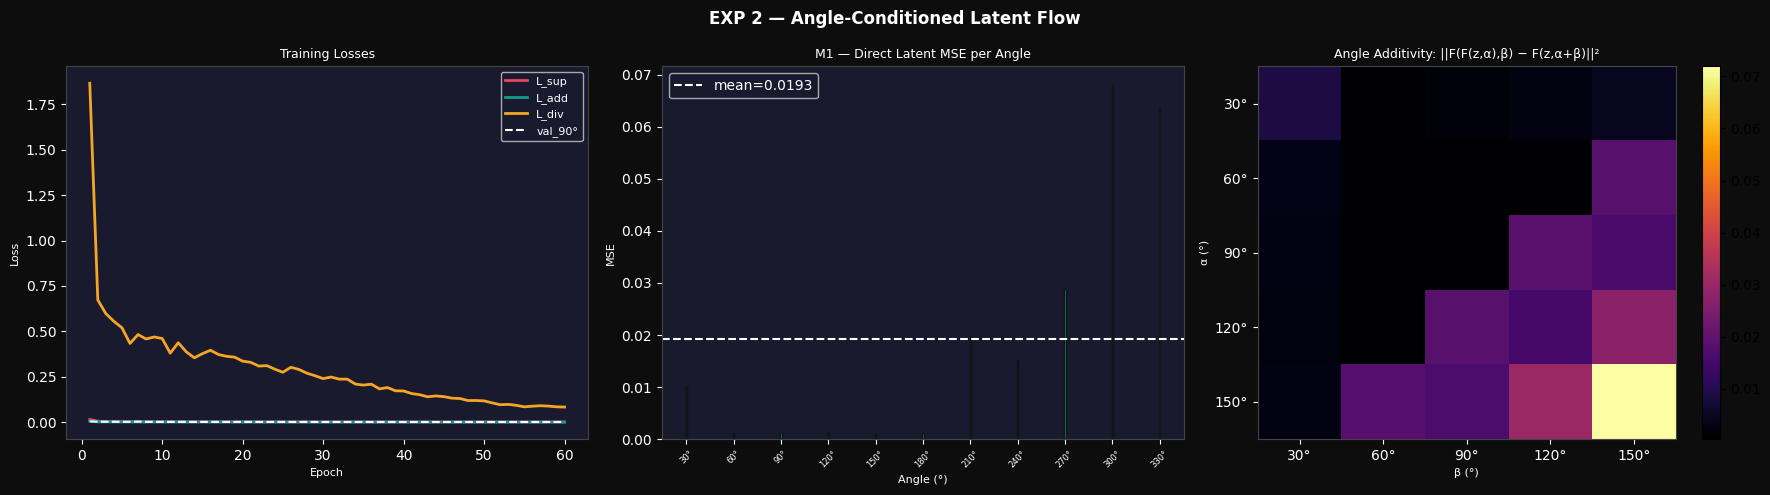

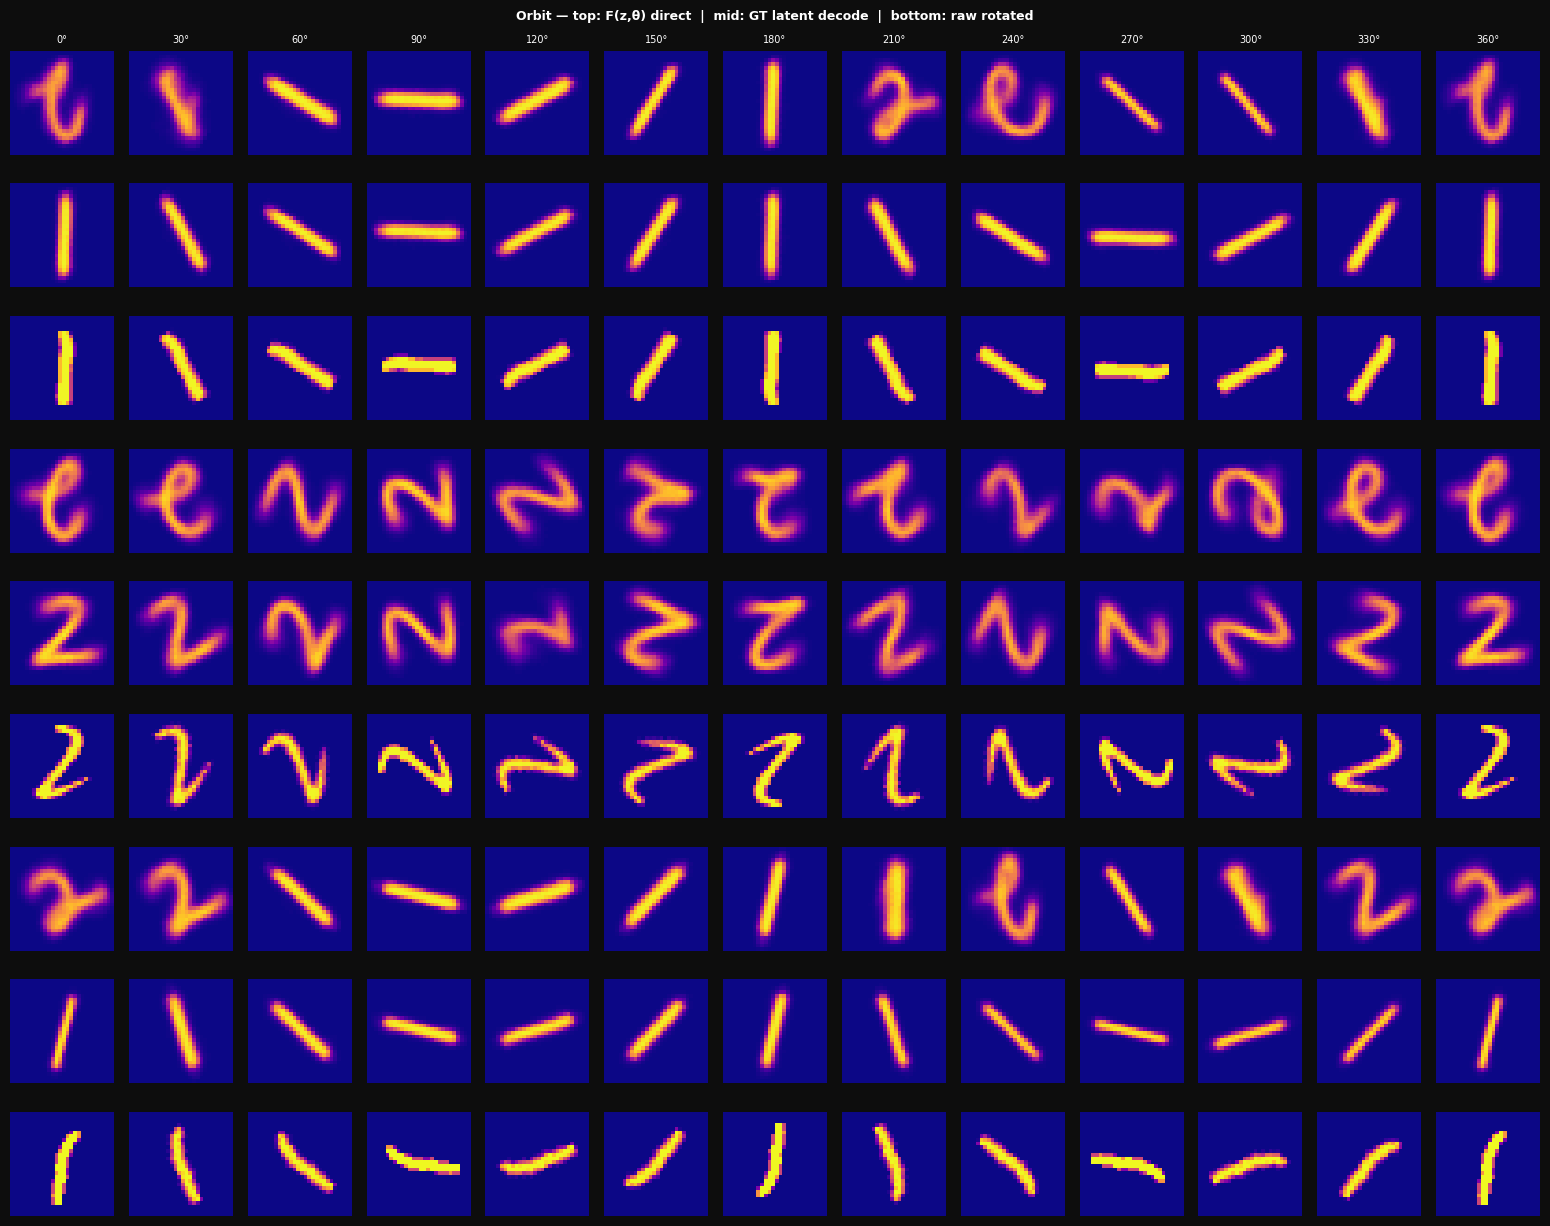


✅ EXP 2 (Angle-Conditioned Flow) complete
   M1=0.01928  M2=0.00011  M4_add=0.00036  M5_pix=0.03946


In [10]:
DARK = "#0d0d0d"; PANEL = "#1a1a2e"
 
def _ax(ax, title="", xl="", yl=""):
    ax.set_facecolor(PANEL); ax.tick_params(colors="white")
    for s in ax.spines.values(): s.set_edgecolor("#444")
    if title: ax.set_title(title, color="white", fontsize=9)
    if xl:    ax.set_xlabel(xl, color="white", fontsize=8)
    if yl:    ax.set_ylabel(yl, color="white", fontsize=8)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=DARK)
fig.suptitle("EXP 2 — Angle-Conditioned Latent Flow", color="white", fontsize=12, fontweight="bold")
 
ep_ax = range(1, EPOCHS_F + 1)
_ax(axes[0], "Training Losses", "Epoch", "Loss")
axes[0].plot(ep_ax, history["sup"],    color="#e94560", lw=2, label="L_sup")
axes[0].plot(ep_ax, history["add"],    color="#0f9b8e", lw=2, label="L_add")
axes[0].plot(ep_ax, history["div"],    color="#f5a623", lw=2, label="L_div")
axes[0].plot(ep_ax, history["val_90"], color="white",   lw=1.5, ls="--", label="val_90°")
axes[0].legend(facecolor=PANEL, labelcolor="white", fontsize=8)
 
_ax(axes[1], "M1 — Direct Latent MSE per Angle", "Angle (°)", "MSE")
axes[1].bar(list(m1_per.keys()), list(m1_per.values()),
            color="#0f9b8e", alpha=0.85, edgecolor=DARK)
axes[1].axhline(m1_mean, color="white", ls="--", lw=1.5, label=f"mean={m1_mean:.4f}")
axes[1].set_xticks(list(m1_per.keys()))
axes[1].set_xticklabels([f"{a}°" for a in m1_per.keys()], color="white", fontsize=6, rotation=45)
axes[1].legend(facecolor=PANEL, labelcolor="white")
 
# angle error heatmap (additivity check: F(F(z,α),β) vs F(z,α+β))
with torch.no_grad():
    pool = (test_angs == 0).nonzero(as_tuple=True)[0][:200]
    z_p  = test_imgs[pool].to(device)
    z_p, _ = vae.encode(z_p)
    check_angles = [30, 60, 90, 120, 150]
    grid = np.zeros((len(check_angles), len(check_angles)))
    for i, a in enumerate(check_angles):
        for j, b in enumerate(check_angles):
            ab = (a + b) % 360
            if ab == 0: ab = 360
            z_ab_dir  = F_net(z_p, float(ab))
            z_a_then_b = F_net(F_net(z_p, float(a)), float(b))
            grid[i, j] = F.mse_loss(z_a_then_b, z_ab_dir).item()
 
_ax(axes[2], "Angle Additivity: ||F(F(z,α),β) − F(z,α+β)||²", "β (°)", "α (°)")
im = axes[2].imshow(grid, cmap="inferno", aspect="auto")
axes[2].set_xticks(range(len(check_angles)))
axes[2].set_xticklabels([f"{a}°" for a in check_angles], color="white")
axes[2].set_yticks(range(len(check_angles)))
axes[2].set_yticklabels([f"{a}°" for a in check_angles], color="white")
plt.colorbar(im, ax=axes[2])
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "results.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()
 
# ── orbit: direct angle prediction (no rollout!) ──────────────────────────────
@torch.no_grad()
def plot_orbit(n_samples: int = 3):
    pool = (test_angs == 0).nonzero(as_tuple=True)[0][:n_samples]
    x0   = test_imgs[pool].to(device)
    z0, _ = vae.encode(x0)
 
    angles_show = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360]
    n_show = len(angles_show)
 
    fig, axes = plt.subplots(n_samples * 3, n_show, figsize=(n_show * 1.2, n_samples * 4.2), facecolor=DARK)
    fig.suptitle("Orbit — top: F(z,θ) direct  |  mid: GT latent decode  |  bottom: raw rotated",
                 color="white", fontsize=9, fontweight="bold")
 
    for row in range(n_samples):
        for col, angle in enumerate(angles_show):
            th_eff = angle if angle != 360 else 360
            xr = x0[row:row+1] if angle == 0 else tvrotate(
                x0[row:row+1], float(angle % 360),
                interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
 
            # direct prediction
            z_pred = F_net(z0[row:row+1], float(th_eff))
            pred   = vae.decode(z_pred).clamp(0.,1.).cpu().squeeze().numpy()
            axes[row*3,   col].imshow(pred, cmap="plasma", vmin=0, vmax=1)
            axes[row*3,   col].axis("off")
 
            # GT
            z_gt, _ = vae.encode(xr)
            gt_dec  = vae.decode(z_gt).clamp(0.,1.).cpu().squeeze().numpy()
            axes[row*3+1, col].imshow(gt_dec, cmap="plasma", vmin=0, vmax=1)
            axes[row*3+1, col].axis("off")
 
            # raw
            axes[row*3+2, col].imshow(xr.cpu().squeeze().numpy(), cmap="plasma", vmin=0, vmax=1)
            axes[row*3+2, col].axis("off")
 
            if row == 0:
                axes[0, col].set_title(f"{angle}°", color="white", fontsize=7)
 
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "orbit.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
 
plot_orbit()
 
print(f"\n✅ EXP 2 (Angle-Conditioned Flow) complete")
print(f"   M1={m1_mean:.5f}  M2={m2:.5f}  M4_add={m4:.5f}  M5_pix={m5:.5f}")